In [ ]:
%matplotlib inline
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import balanced_accuracy_score
import scipy.io
import random

np.random.seed(1)
tf.random.set_seed(1)
random.seed(1)

In [ ]:
data = scipy.io.loadmat('shuttle.mat')

X = data['X']
y = data['y'].ravel() 

# split (50% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=1, stratify=y)

# Min-max normalization 
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

print('Train shape:', X_train_norm.shape, 'Test shape:', X_test_norm.shape)

Train shape: (24548, 9) Test shape: (24549, 9)


In [ ]:
class Autoencoder(keras.Model):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = keras.Sequential([
            layers.Dense(8, activation='relu', input_shape=(input_dim,)),
            layers.Dense(5, activation='relu'),
            layers.Dense(3, activation='relu'),
        ])
        self.decoder = keras.Sequential([
            layers.Dense(5, activation='relu', input_shape=(3,)),
            layers.Dense(8, activation='relu'),
            layers.Dense(input_dim, activation='sigmoid'),
        ])
    def call(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

input_dim = X_train_norm.shape[1]
autoencoder = Autoencoder(input_dim)

e:\master\AnomalyDetection\.venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
24/24 - 1s - 46ms/step - loss: 0.0281 - val_loss: 0.0270
Epoch 2/100
24/24 - 0s - 4ms/step - loss: 0.0266 - val_loss: 0.0255
Epoch 3/100
24/24 - 0s - 4ms/step - loss: 0.0251 - val_loss: 0.0242
Epoch 4/100
24/24 - 0s - 4ms/step - loss: 0.0238 - val_loss: 0.0229
Epoch 5/100
24/24 - 0s - 4ms/step - loss: 0.0226 - val_loss: 0.0217
Epoch 6/100
24/24 - 0s - 4ms/step - loss: 0.0214 - val_loss: 0.0206
Epoch 7/100
24/24 - 0s - 4ms/step - loss: 0.0203 - val_loss: 0.0195
Epoch 8/100
24/24 - 0s - 4ms/step - loss: 0.0193 - val_loss: 0.0186
Epoch 9/100
24/24 - 0s - 4ms/step - loss: 0.0183 - val_loss: 0.0177
Epoch 10/100
24/24 - 0s - 4ms/step - loss: 0.0175 - val_loss: 0.0168
Epoch 11/100
24/24 - 0s - 4ms/step - loss: 0.0166 - val_loss: 0.0160
Epoch 12/100
24/24 - 0s - 4ms/step - loss: 0.0158 - val_loss: 0.0151
Epoch 13/100
24/24 - 0s - 4ms/step - loss: 0.0149 - val_loss: 0.0142
Epoch 14/100
24/24 - 0s - 4ms/step - loss: 0.0138 - val_loss: 0.0129
Epoch 15/100
24/24 - 0s - 4ms/step - loss:

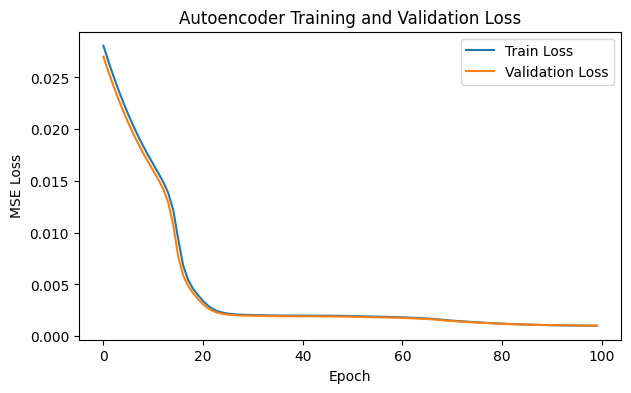

In [ ]:
autoencoder.compile(optimizer='adam', loss='mse')

history = autoencoder.fit(
    X_train_norm, X_train_norm,
    epochs=100,
    batch_size=1024,
    shuffle=True,
    validation_data=(X_test_norm, X_test_norm),
    verbose=2
)

# Plot training and validation loss
plt.figure(figsize=(7, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
recon_train = autoencoder.predict(X_train_norm)
recon_test = autoencoder.predict(X_test_norm)

mse_train = np.mean(np.square(X_train_norm - recon_train), axis=1)
mse_test = np.mean(np.square(X_test_norm - recon_test), axis=1)

# Contamination rate
contamination = np.mean(y_train != 1) if np.any(y_train != 1) else 0.1  # fallback to 0.1 if all normal
threshold = np.quantile(mse_train, 1 - contamination)

# labels: 1=normal, -1=anomaly
train_pred = np.where(mse_train > threshold, -1, 1)
test_pred = np.where(mse_test > threshold, -1, 1)

# True labels: 1=normal, -1=anomaly
train_true = np.where(y_train == 1, 1, -1)
test_true = np.where(y_test == 1, 1, -1)

train_bacc = balanced_accuracy_score(train_true, train_pred)
test_bacc = balanced_accuracy_score(test_true, test_pred)

print(f"Threshold: {threshold:.5f}")
print(f"Balanced accuracy (train): {train_bacc:.4f}")
print(f"Balanced accuracy (test):  {test_bacc:.4f}")

768/768 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step
768/768 ━━━━━━━━━━━━━━━━━━━━ 0s 597us/step
Threshold: 0.00006
Balanced accuracy (train): 0.4618
Balanced accuracy (test):  0.4618
